# Noise-Aware Hybrid Quantum-Classical Financial Fraud Detection

## Midterm results demonstration

This notebook presents the completed classical baselines, the preliminary reduced-subset QSVM experiment, and the saved midterm comparison artifacts.

## 1. Problem statement

Financial fraud detection is an extremely imbalanced binary-classification problem. This project studies classical baselines and a small hybrid quantum-classical kernel pipeline while preserving leakage-free evaluation.

## 2. Research questions

1. How does severe class imbalance affect fraud-detection evaluation?
2. How do classical baselines compare with a preliminary quantum-kernel method?
3. How should later experiments measure temporal distribution shift?
4. How might simulated quantum noise affect quantum-model results?
5. How might feature and qubit scaling affect performance and cost?
6. What computational cost does each approach incur?

Only dataset validation, EDA, preprocessing, classical baselines, feature reduction, preliminary QSVM, and comparison are completed here.

## 3. Dataset

The project uses the local ULB Credit Card Fraud Detection CSV. The original `Time` column is preserved. The saved validation artifact is loaded below; this notebook does not modify the raw dataset.

## 4. Dataset statistics

The following values come from saved dataset-validation and EDA JSON artifacts, not manually entered results.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
JSON_DIRECTORY = PROJECT_ROOT / 'results' / 'json'
EDA_FIGURES = PROJECT_ROOT / 'results' / 'figures' / 'eda'
CLASSICAL_FIGURES = PROJECT_ROOT / 'results' / 'figures' / 'classical'
QSVM_FIGURES = PROJECT_ROOT / 'results' / 'results' / 'figures' / 'qsvm'
QSVM_FIGURES = PROJECT_ROOT / 'results' / 'figures' / 'qsvm'
TABLES_DIRECTORY = PROJECT_ROOT / 'results' / 'tables'

def load_json(filename):
    return json.loads((JSON_DIRECTORY / filename).read_text(encoding='utf-8'))

dataset_summary = load_json('dataset_summary.json')
eda_summary = load_json('eda_summary.json')
preprocessing = load_json('preprocessing_config.json')
classical_results = load_json('classical_results.json')
qsvm_results = load_json('qsvm_results.json')
qsvm_predictions = load_json('qsvm_predictions.json')
comparison = pd.read_csv(TABLES_DIRECTORY / 'midterm_model_comparison.csv')
print('Saved artifacts loaded successfully.')

Saved artifacts loaded successfully.


In [2]:
dataset_table = pd.DataFrame({
    'metric': ['rows', 'columns', 'missing values', 'duplicate rows', 'Time minimum', 'Time maximum', 'fraud percentage'],
    'value': [dataset_summary['row_count'], dataset_summary['column_count'], dataset_summary['missing_values_total'], dataset_summary['duplicate_row_count'], dataset_summary['time_min'], dataset_summary['time_max'], dataset_summary['fraud_percentage']],
})
display(dataset_table)

,metric,value
0,rows,284807.000000
1,columns,31.000000
2,missing values,0.000000
3,duplicate rows,1081.000000
4,Time minimum,0.000000
5,Time maximum,172792.000000
6,fraud percentage,0.172749


## 5. Class imbalance

The saved summary reports 284,315 non-fraud rows and 492 fraud rows, with fraud at approximately 0.173%. Accuracy is not primary: a classifier can be highly accurate while missing the minority fraud class. PR-AUC, reported as Average Precision, is emphasized because it evaluates precision-recall behavior for the rare positive class.

In [3]:
class_counts = pd.DataFrame({
    'class_label': ['non-fraud (0)', 'fraud (1)'],
    'count': [dataset_summary['class_distribution']['0'], dataset_summary['class_distribution']['1']],
})
display(class_counts)

,class_label,count
0,non-fraud (0),284315
1,fraud (1),492


## 6. EDA

EDA was completed from the unchanged dataset. The existing figures below are displayed from `results/figures/eda/`; this notebook does not regenerate them.

01_class_distribution.png


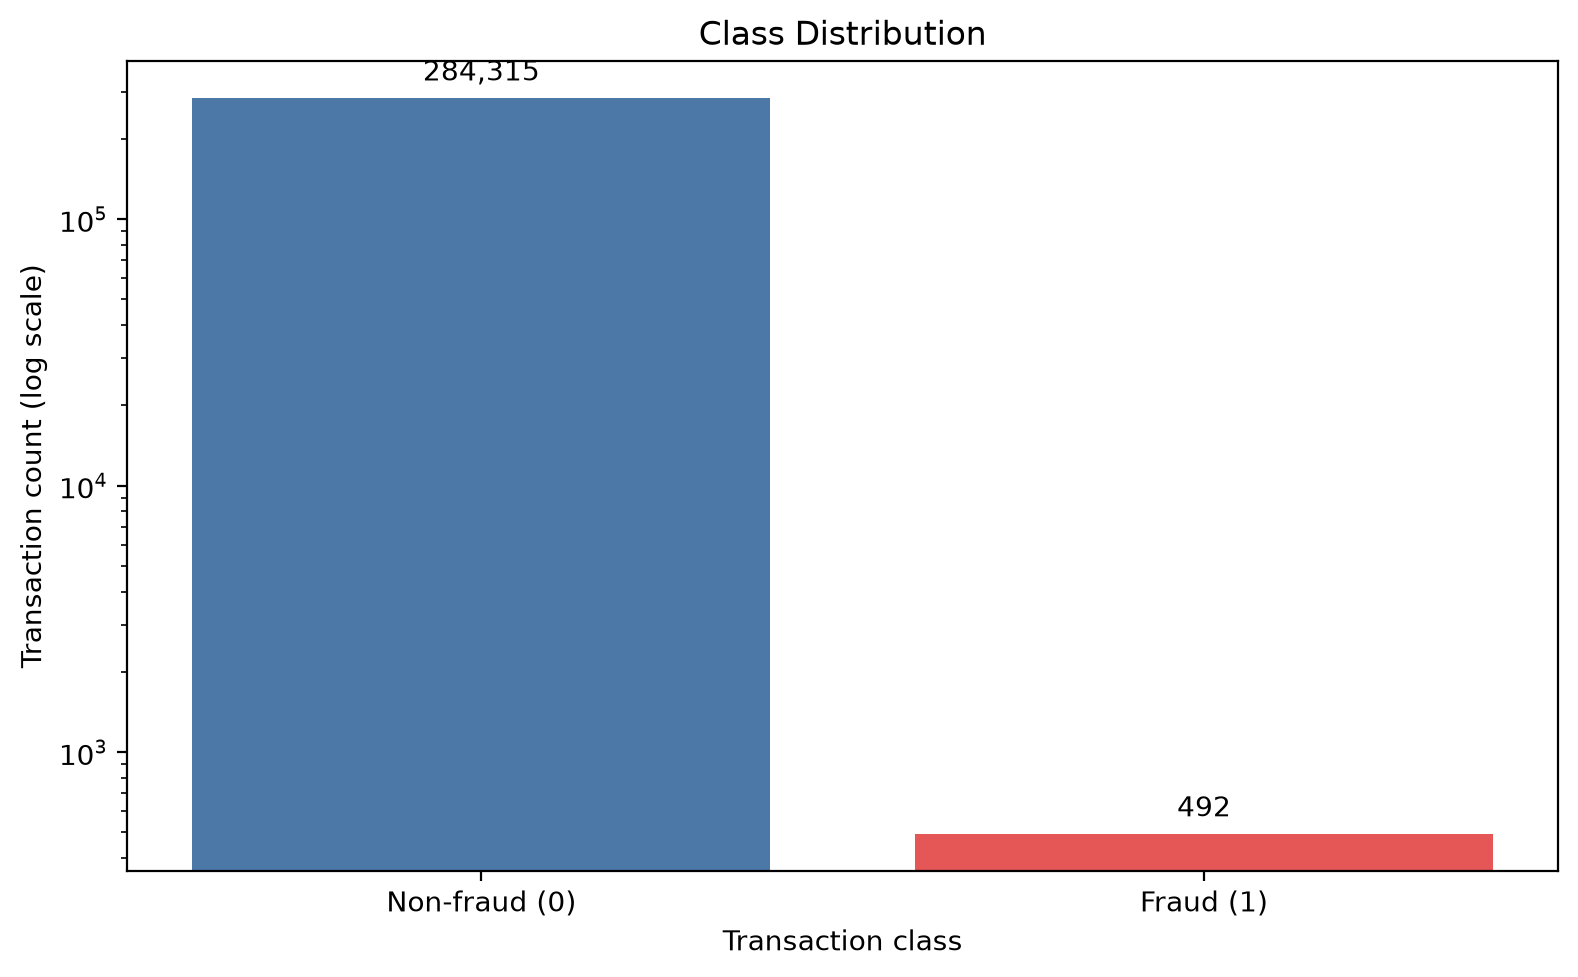

02_fraud_percentage.png


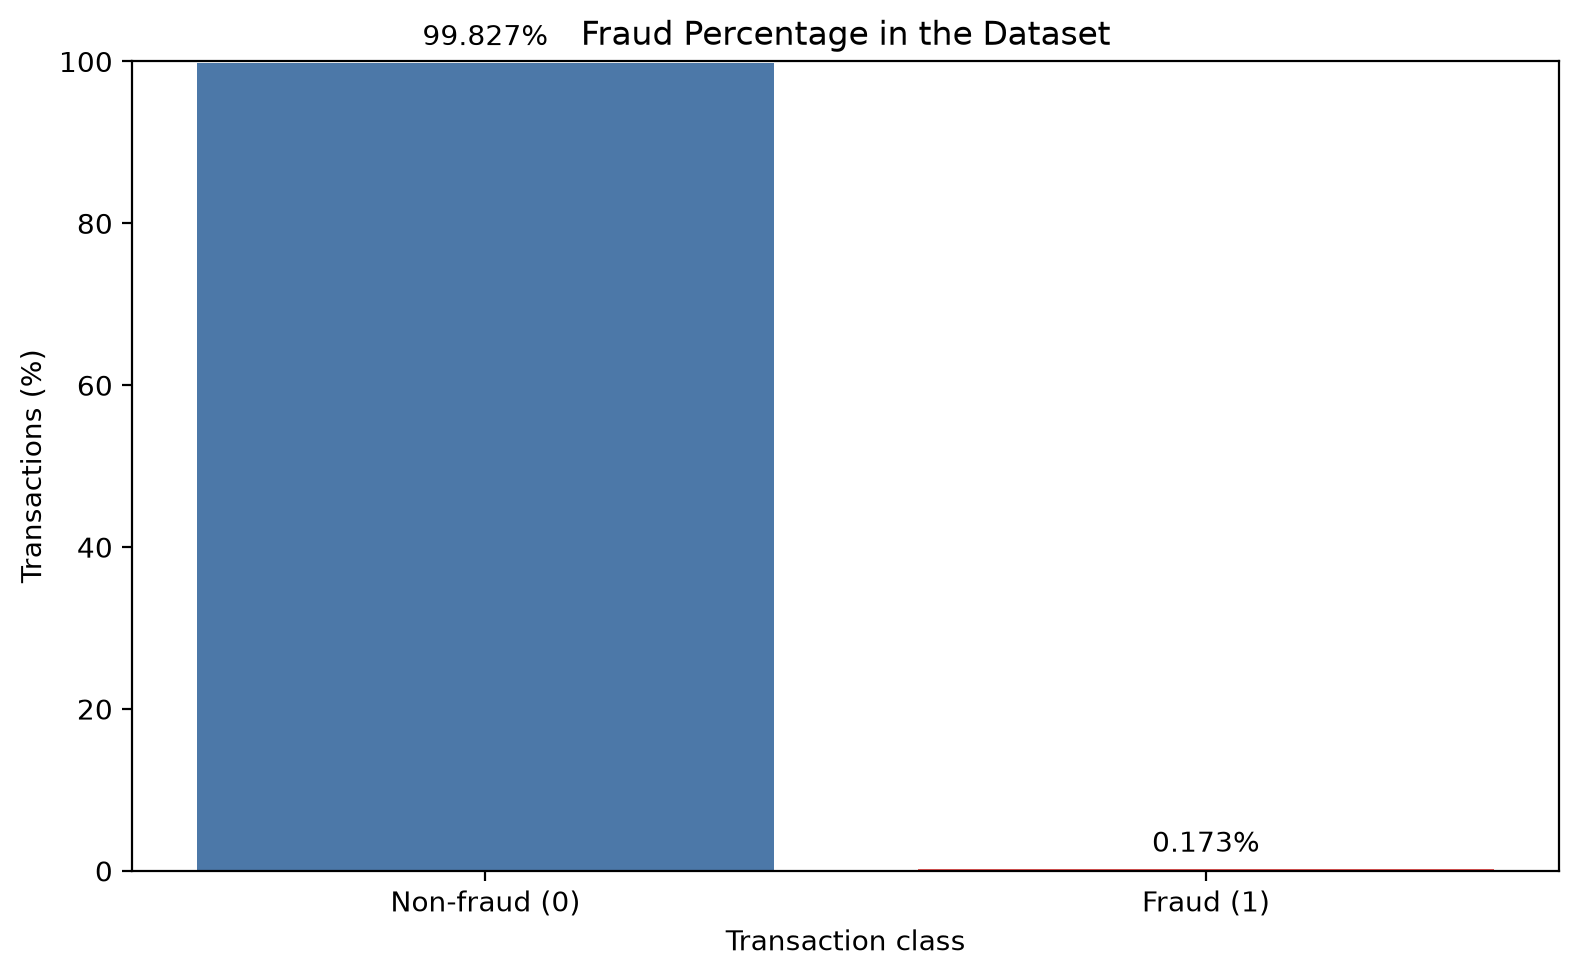

03_amount_distribution.png


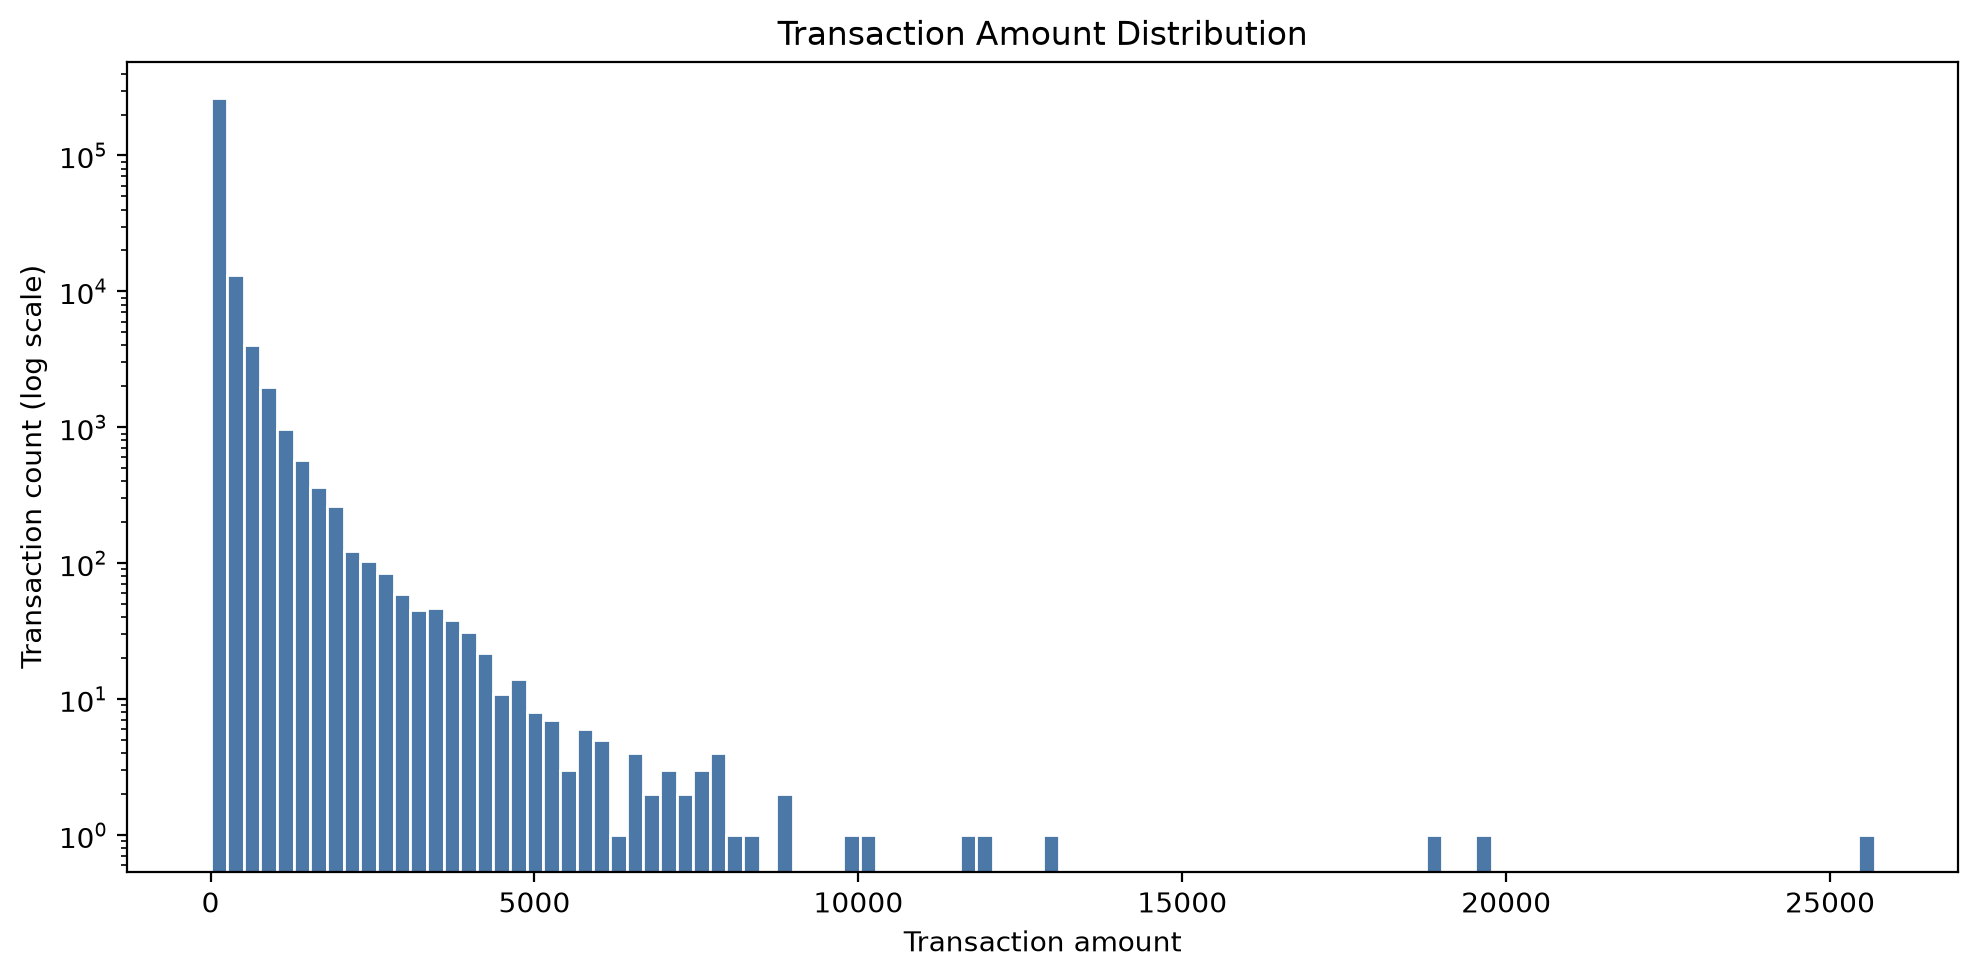

04_time_distribution.png


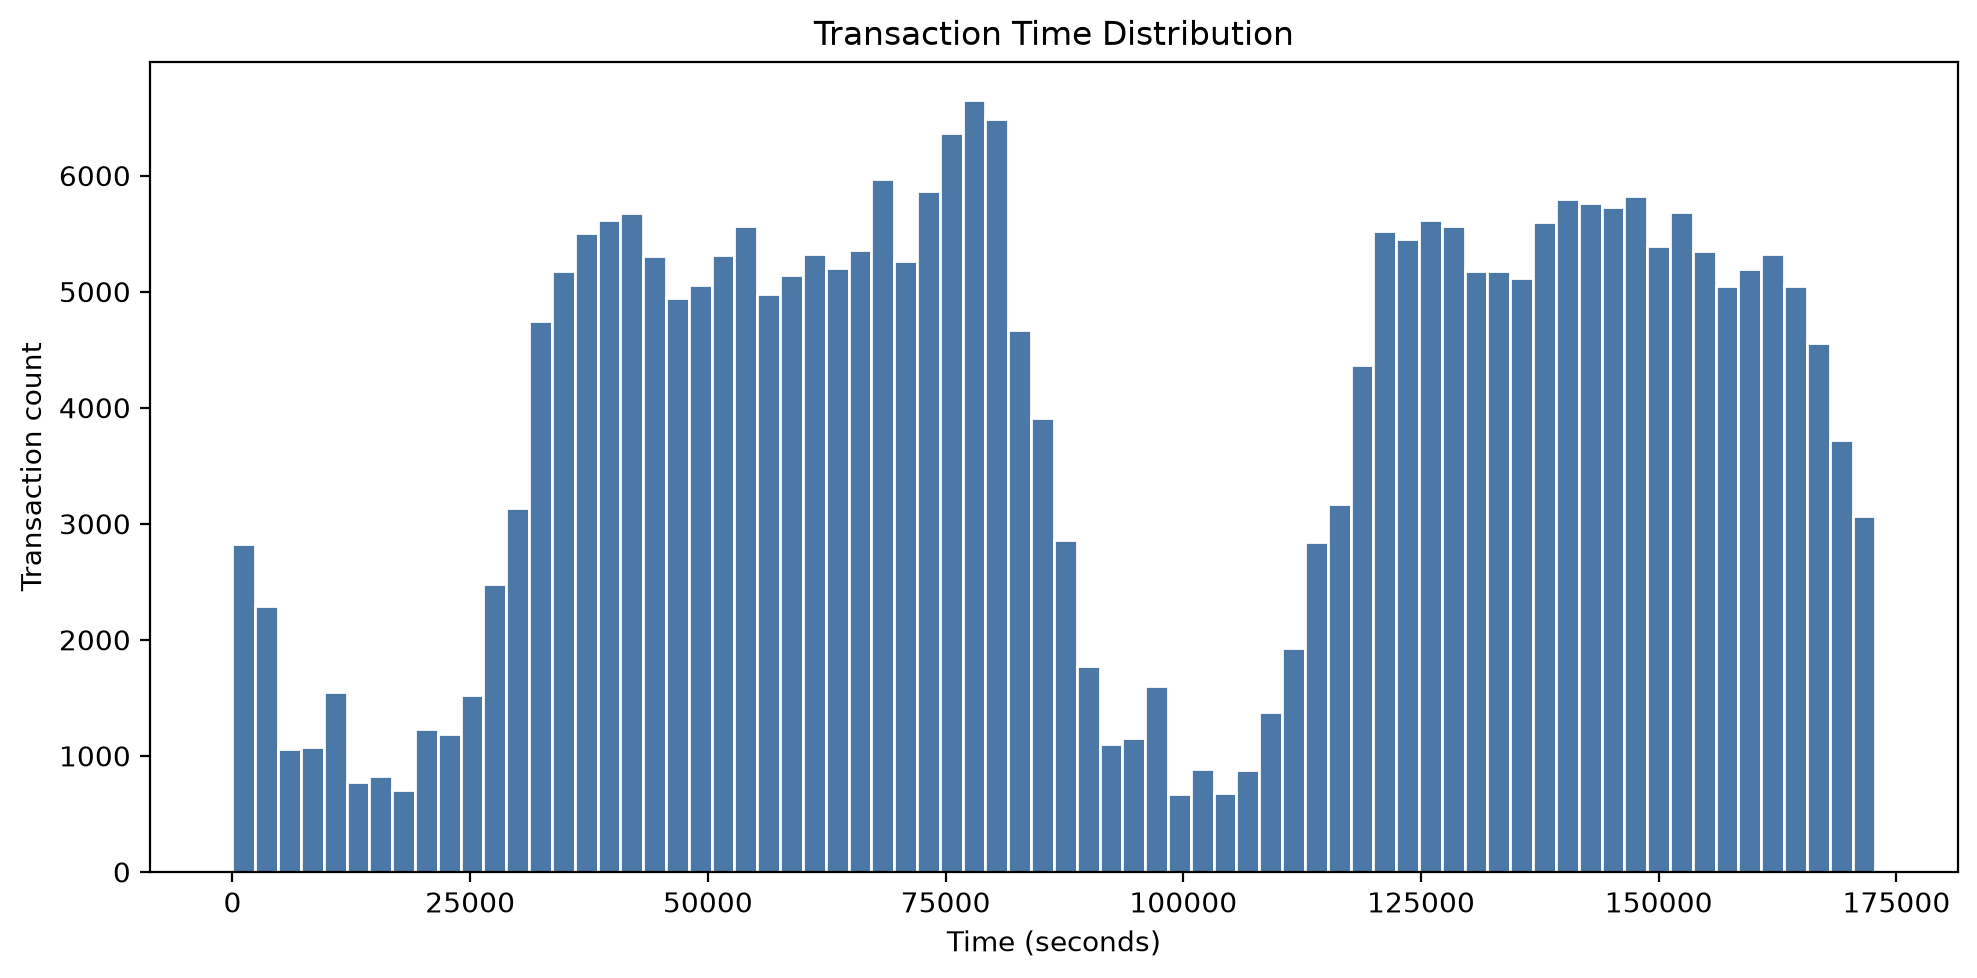

05_fraud_transactions_over_time.png


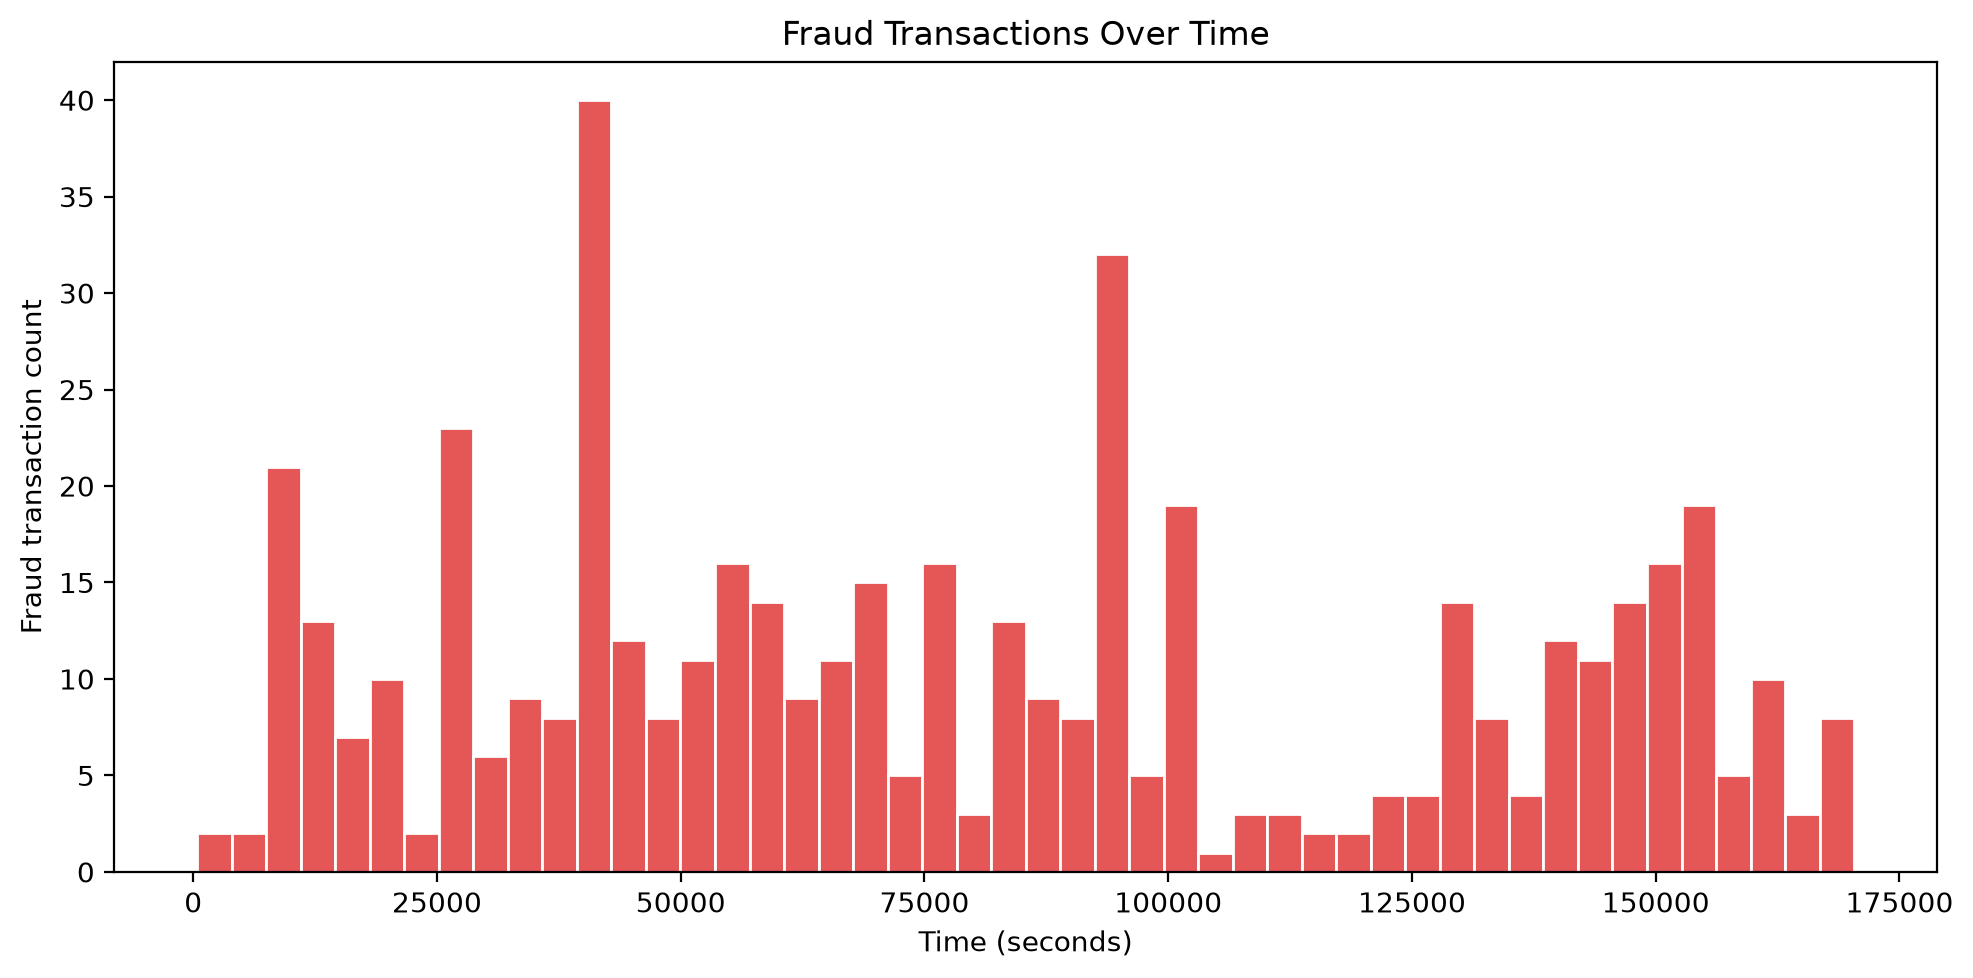

06_amount_distribution_by_class.png


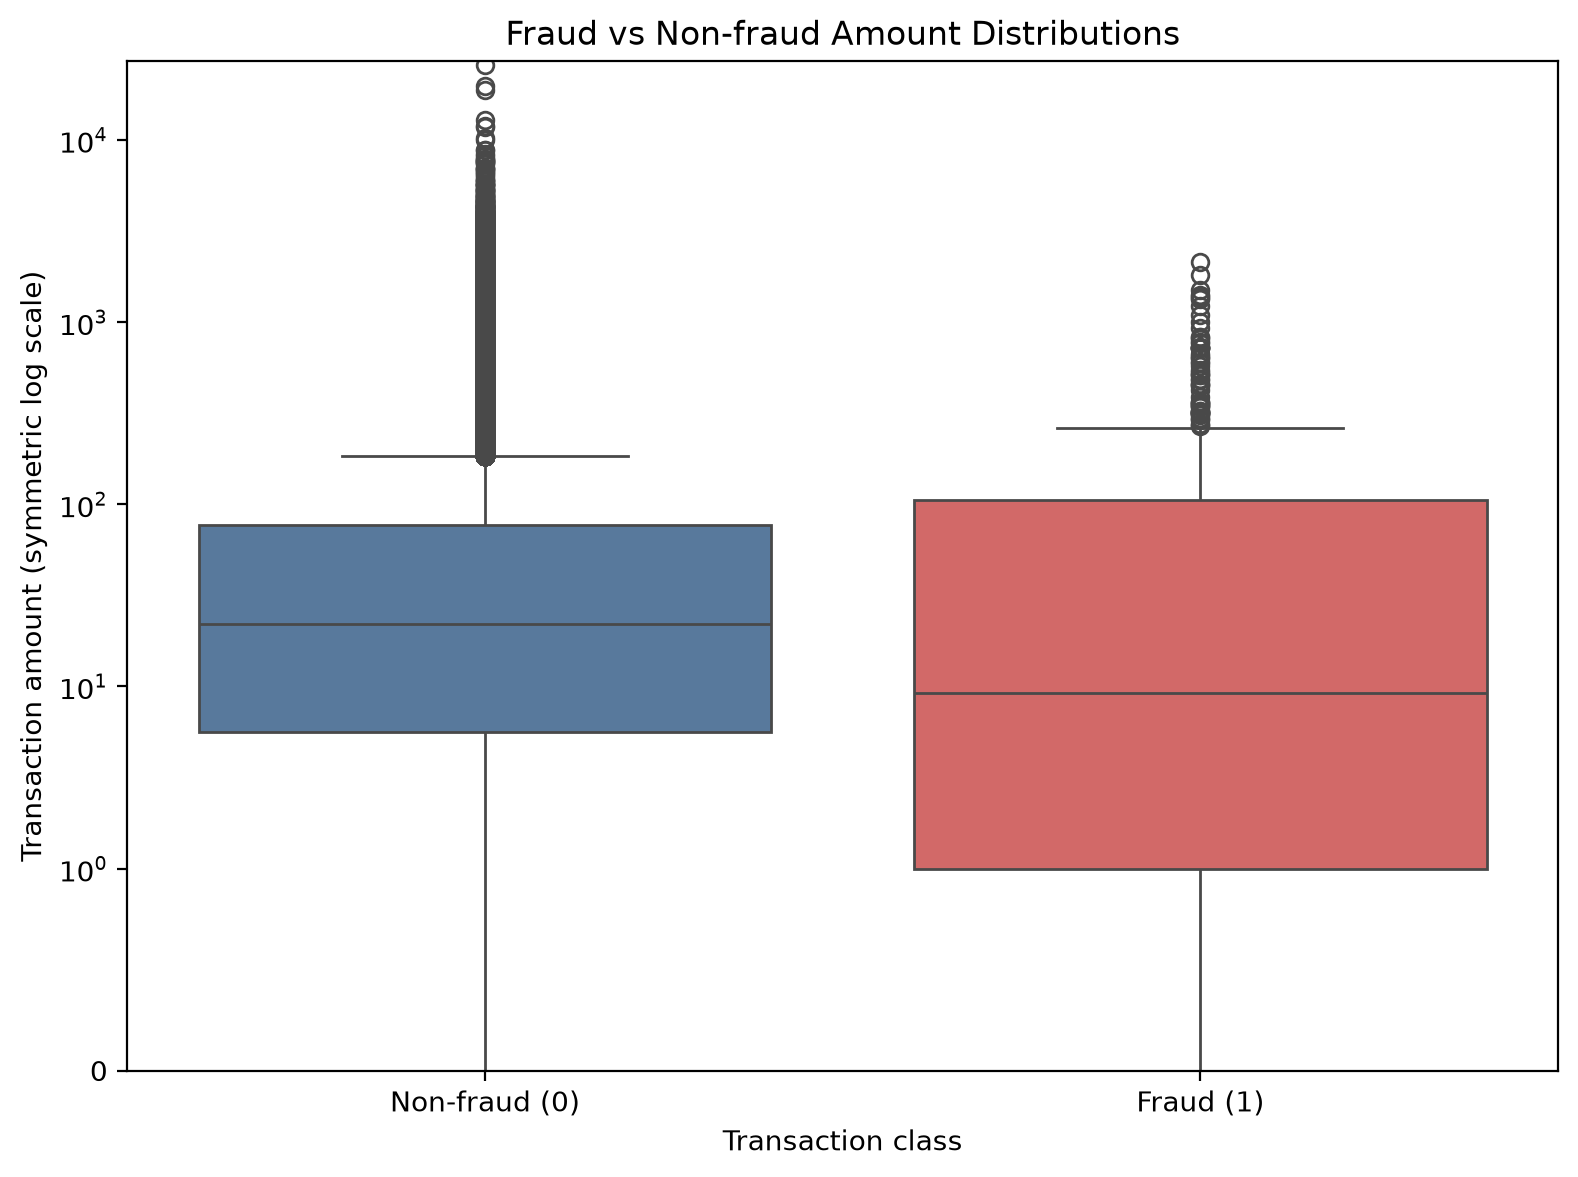

07_selected_feature_distributions.png


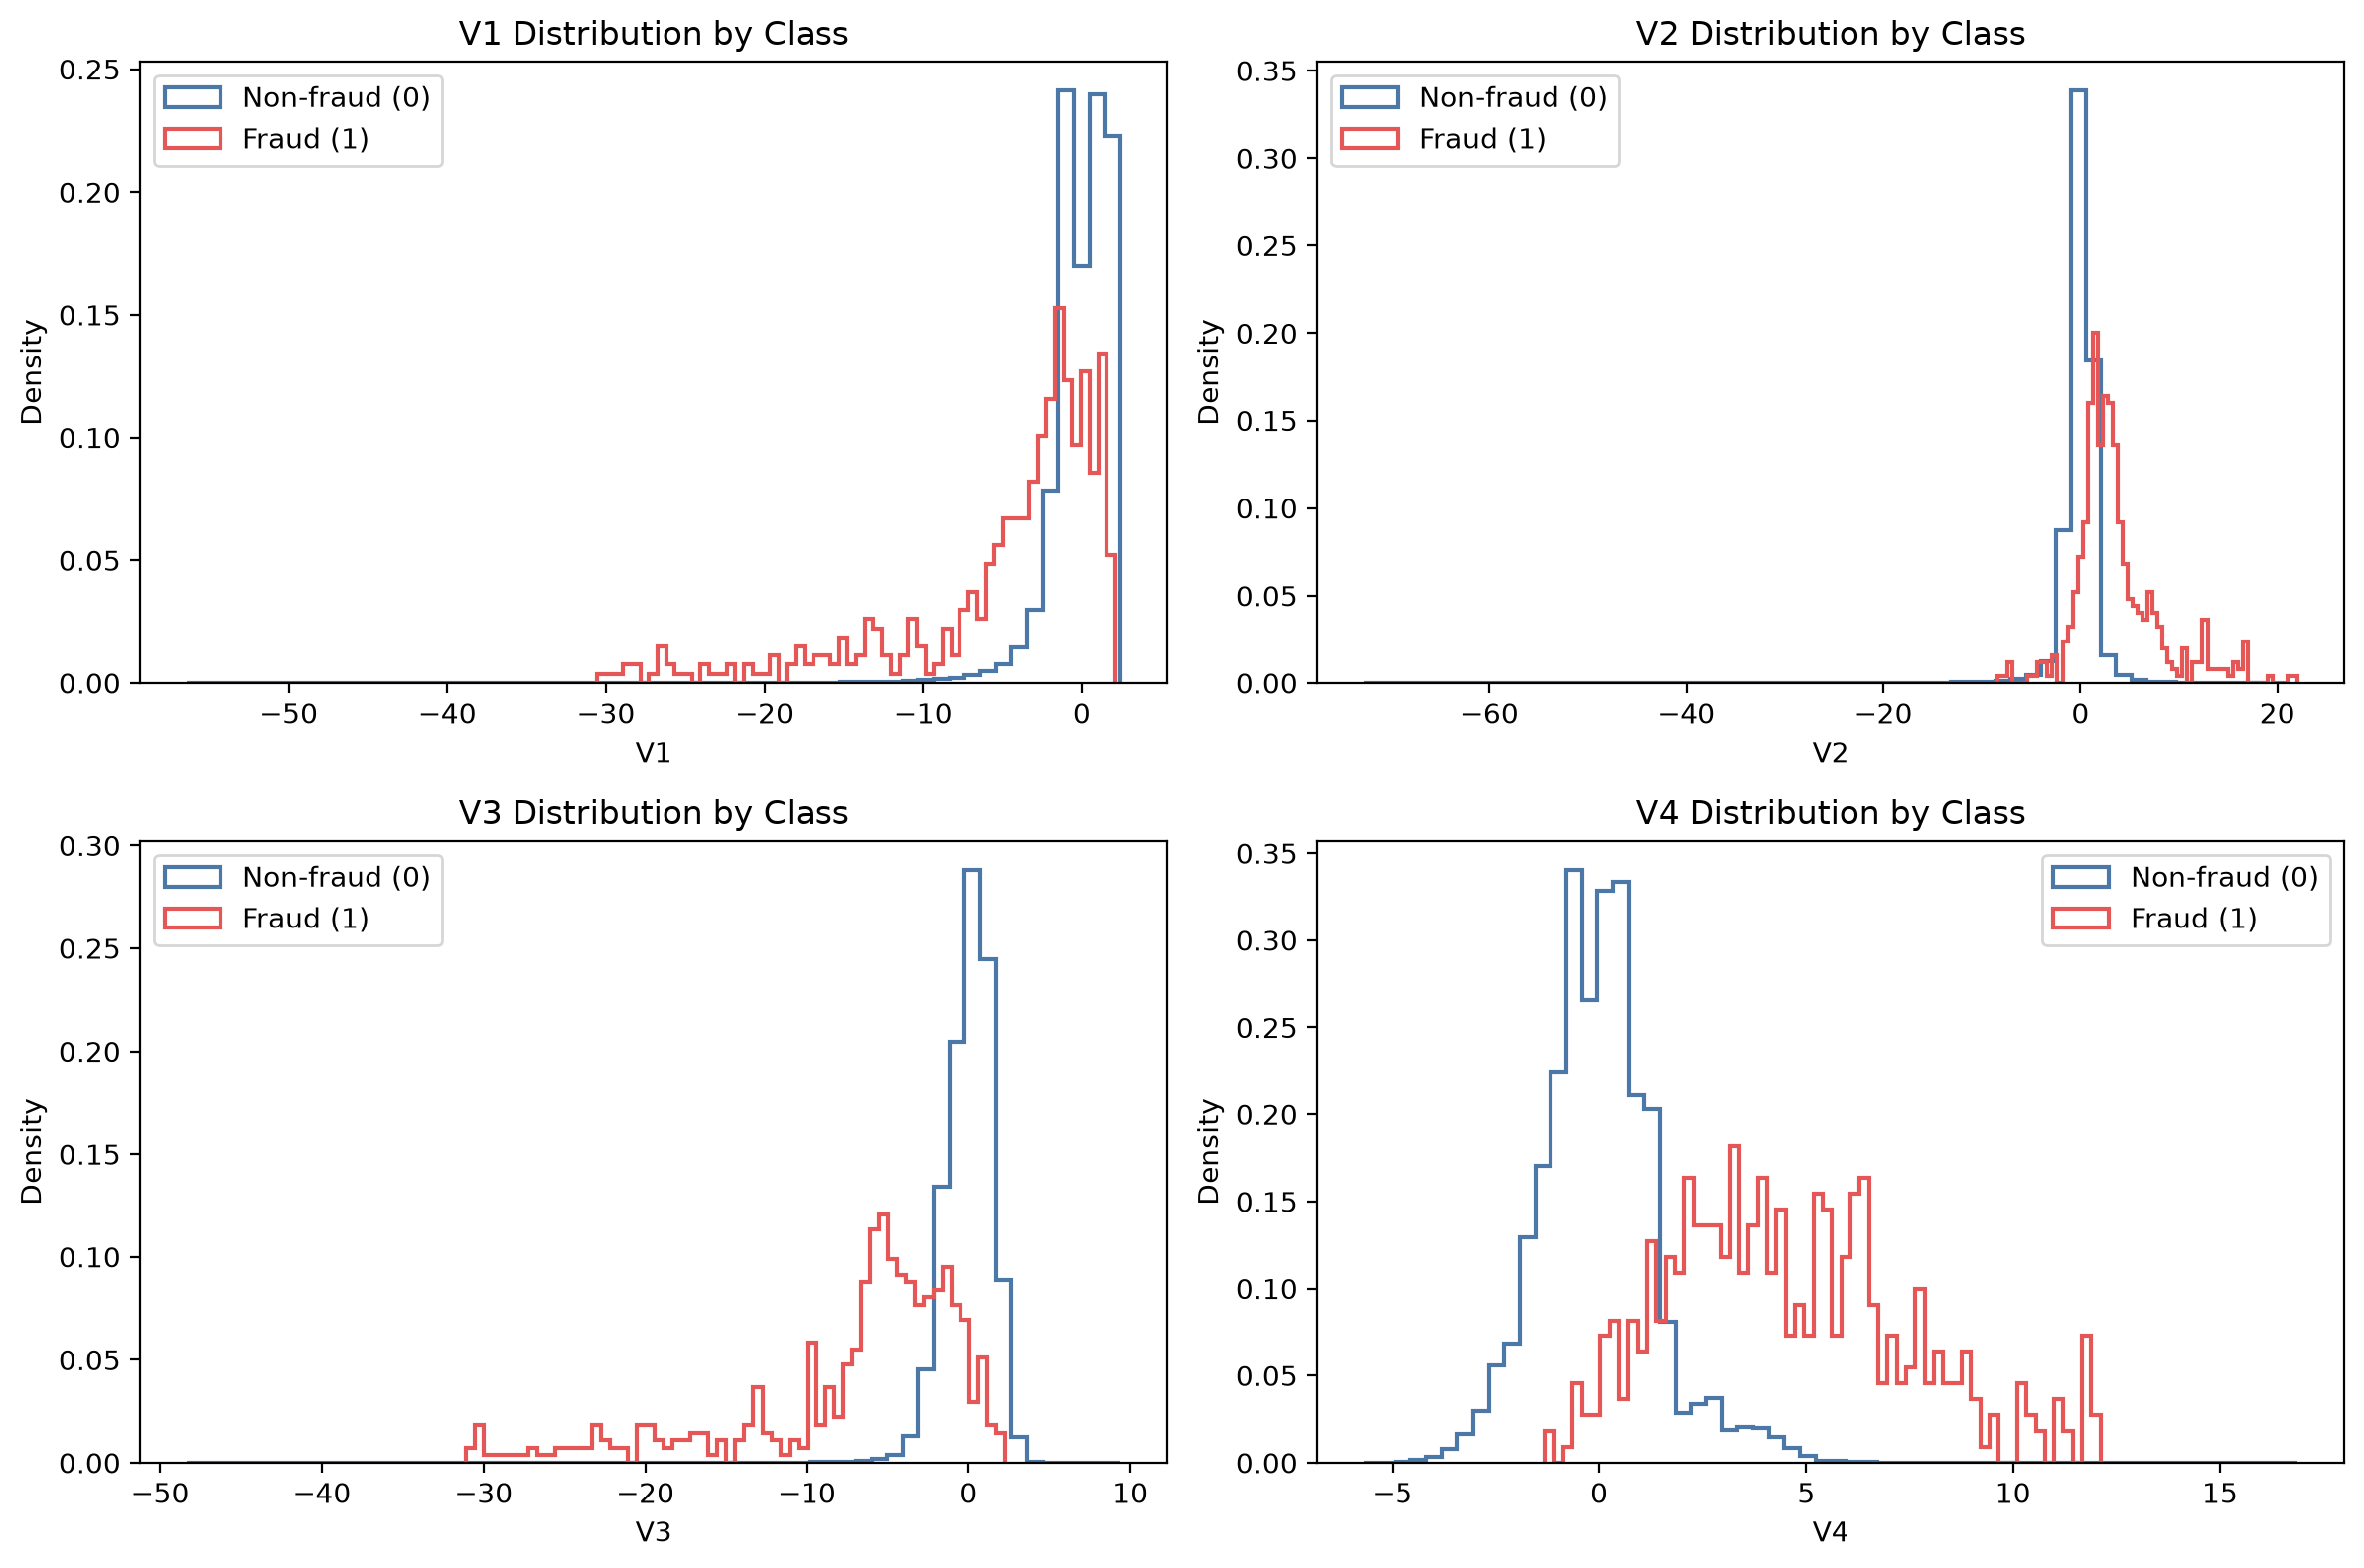

08_correlation_heatmap.png


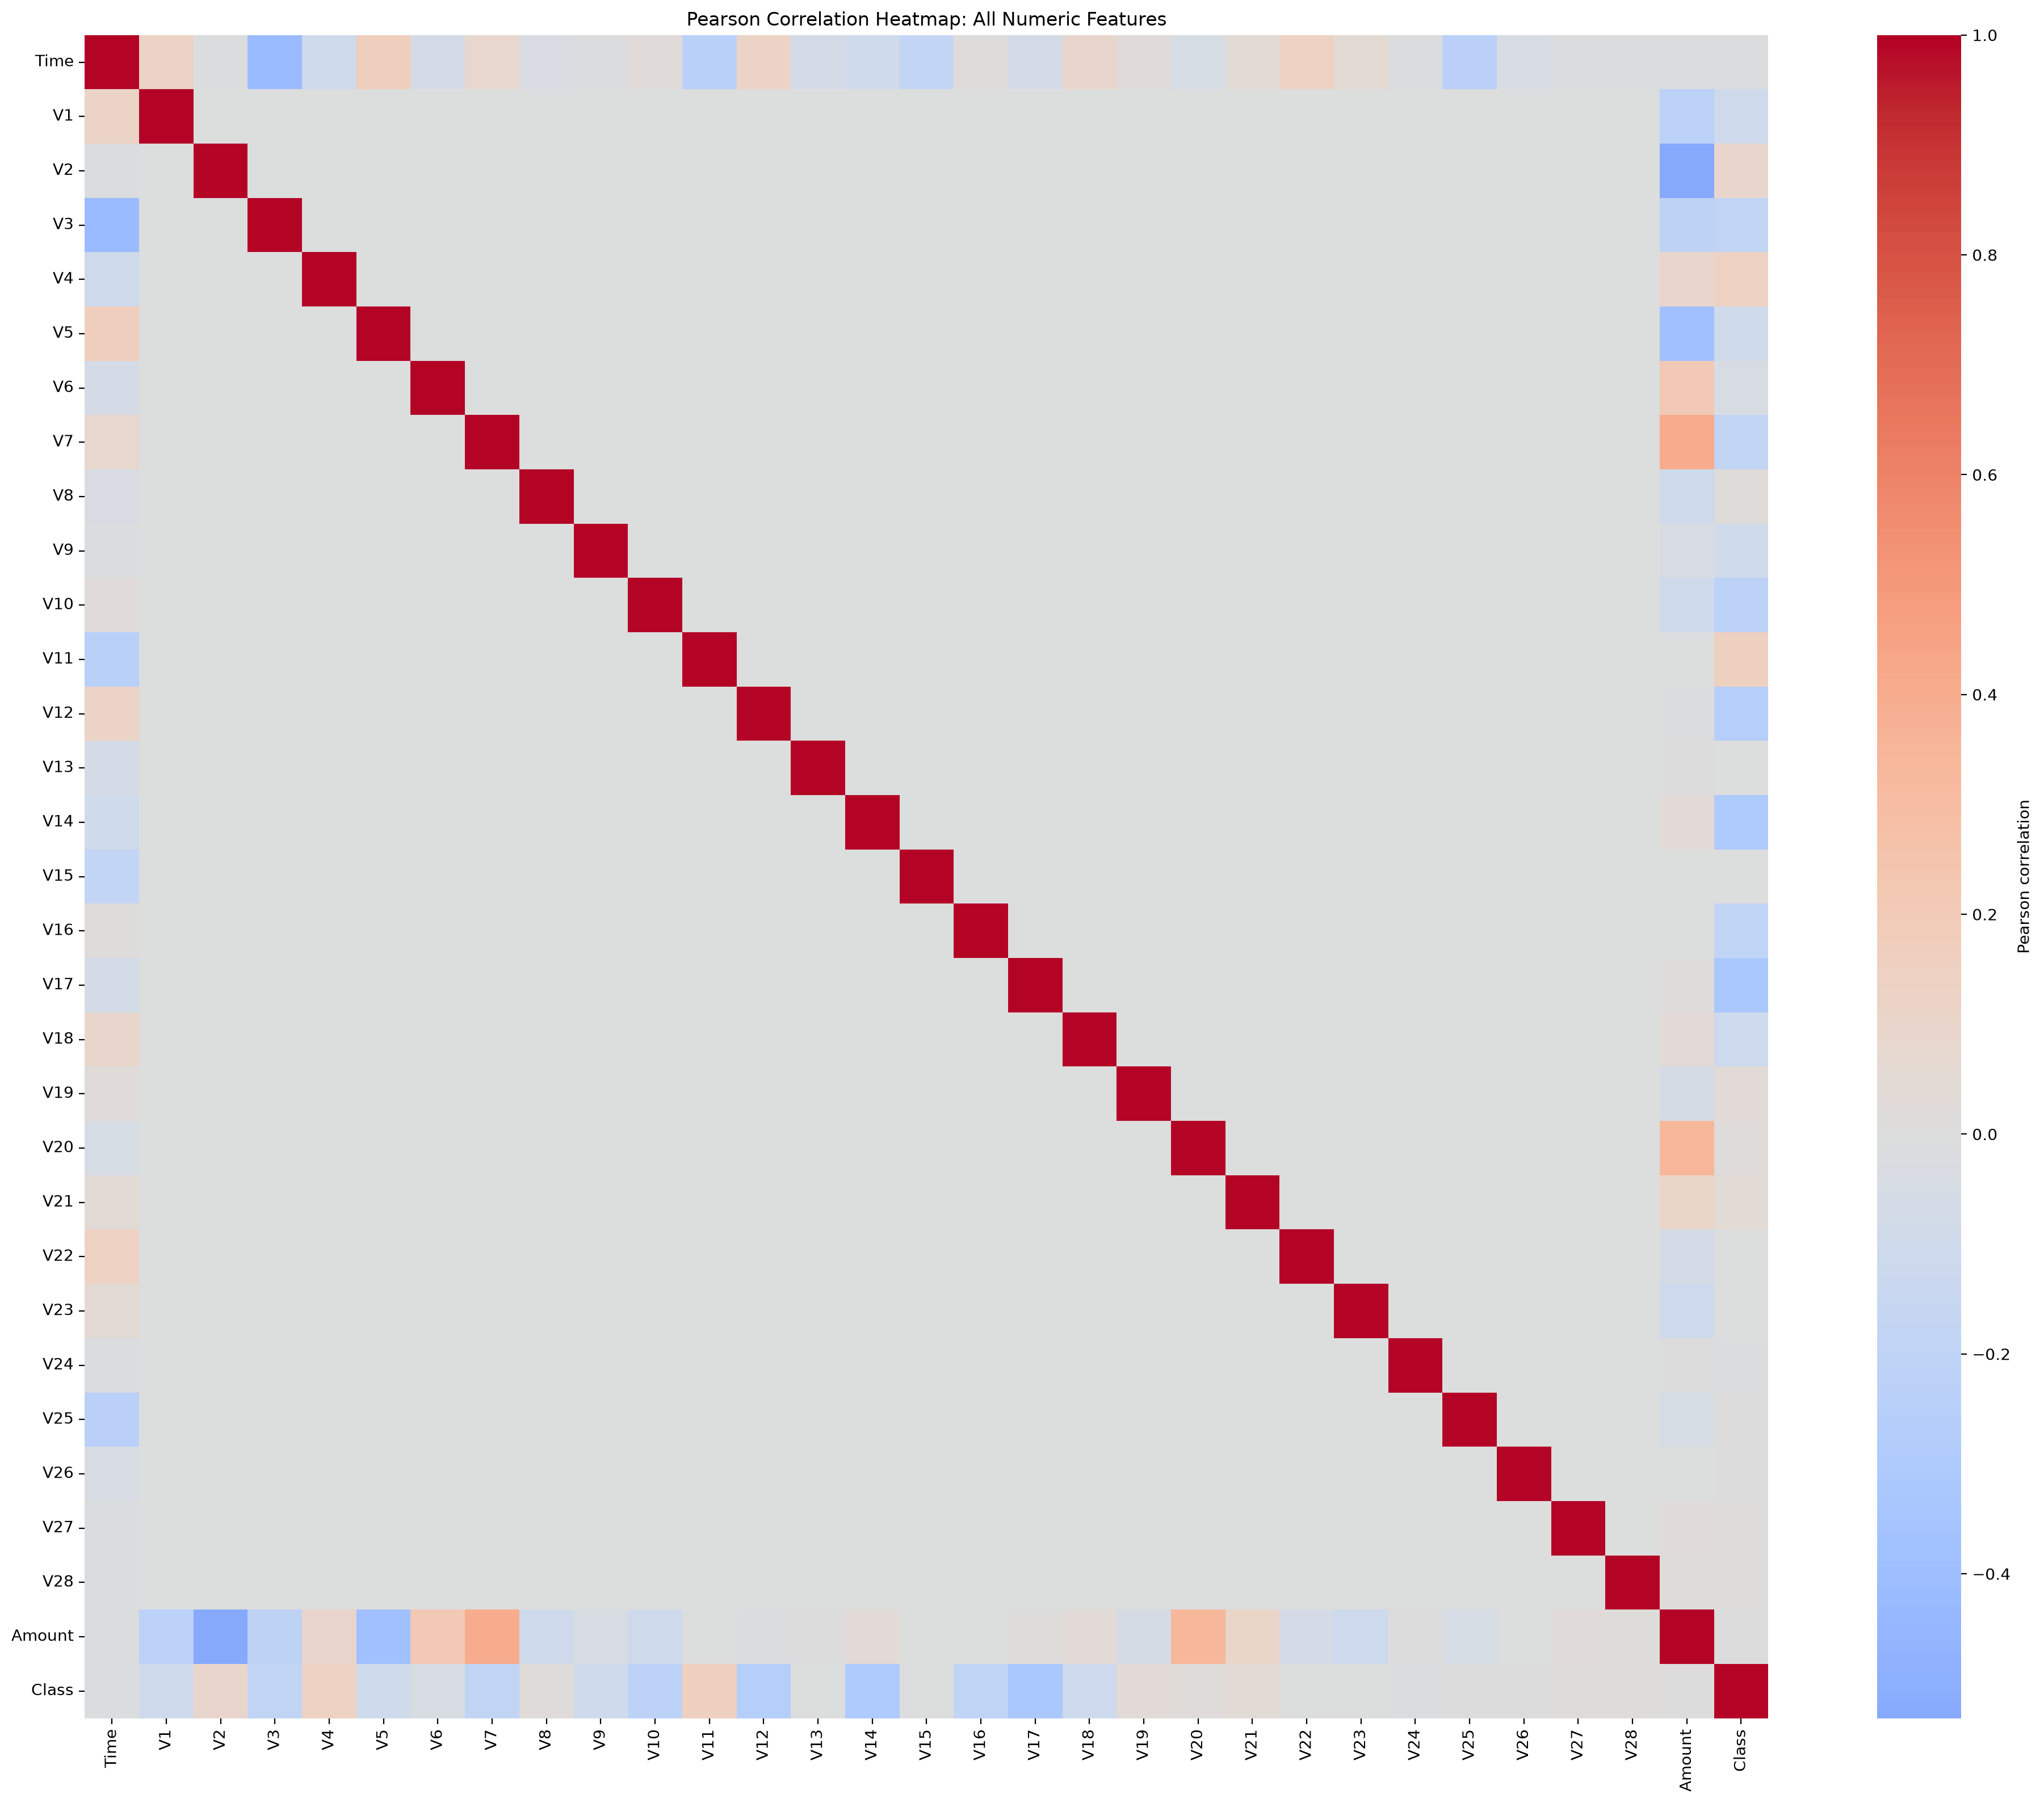

09_fraud_rate_by_time_bin.png


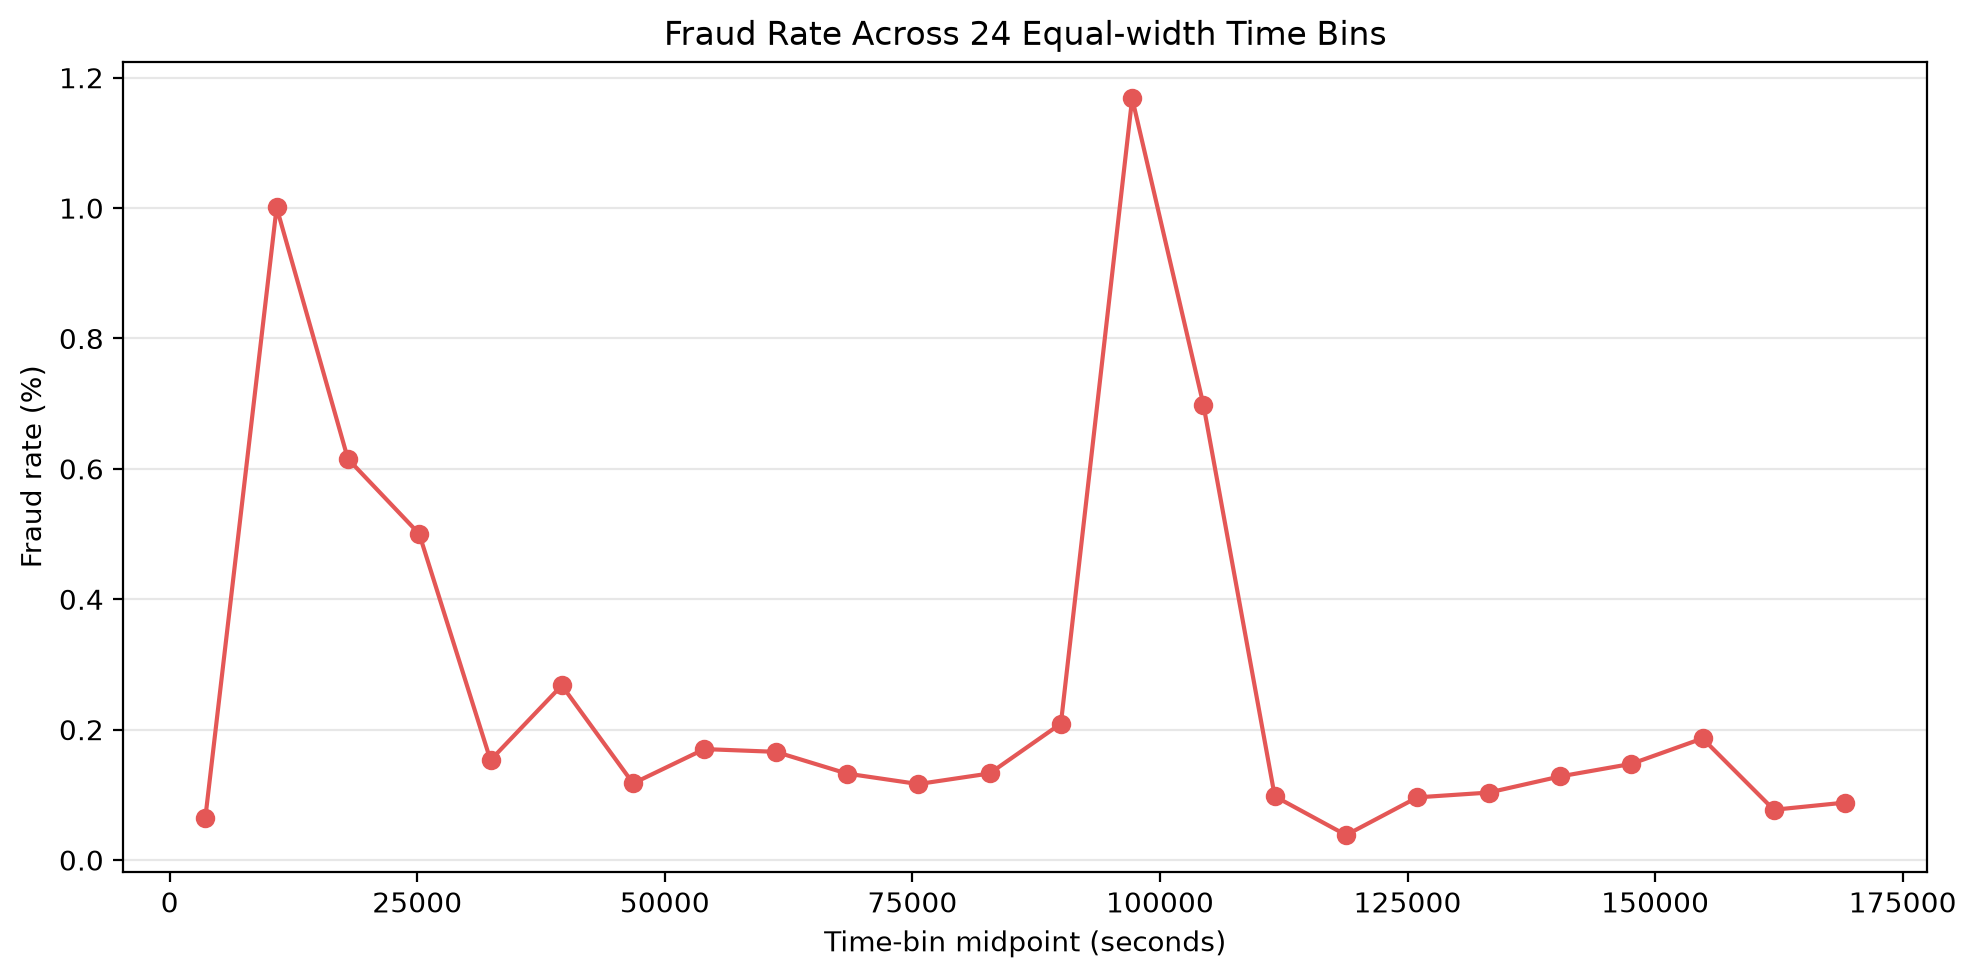

In [4]:
for figure_name in eda_summary['generated_figures']:
    print(figure_name)
    display(Image(filename=str(EDA_FIGURES / figure_name), width=700))

## 7. Preprocessing

The baseline protocol uses the same deterministic 80/20 stratified random split for all three classical models: seed 42, 227,845 training rows, and 56,962 test rows. All 30 non-target columns are retained, including `Time` and `Amount`. `StandardScaler` is fitted on training features only, and the test partition is transformed afterward.

The quantum selector is fitted on the training representation only and selects `V17`, `V14`, `V12`, and `V10` for four qubits.

In [5]:
split = preprocessing['split']
preprocessing_table = pd.DataFrame({
    'setting': ['strategy', 'random state', 'training rows', 'test rows', 'feature count', 'scaler', 'scaler fit scope'],
    'value': [split['strategy'], split['random_state'], split['train_rows'], split['test_rows'], preprocessing['feature_count'], preprocessing['scaling']['transformer'], preprocessing['scaling']['fit_scope']],
})
display(preprocessing_table)

,setting,value
0,strategy,stratified_random_baseline
1,random state,42
2,training rows,227845
3,test rows,56962
4,feature count,30
5,scaler,StandardScaler
6,scaler fit scope,X_train only


## 8. Classical models

The completed classical models are Logistic Regression, RBF-SVM, and XGBoost. They use the same baseline train/test split, the same 30-feature representation, training-only scaling, and the same evaluation framework.

In [6]:
classical_rows = []
for model_name, model_result in classical_results['models'].items():
    classical_rows.append({
        'model': model_name,
        'PR-AUC': model_result['pr_auc'],
        'ROC-AUC': model_result['roc_auc'],
        'precision': model_result['precision'],
        'recall': model_result['recall'],
        'F1': model_result['f1'],
        'specificity': model_result['specificity'],
        'FPR': model_result['false_positive_rate'],
        'training time (seconds)': model_result['training_time_seconds'],
        'inference time (seconds)': model_result['inference_time_seconds'],
    })
display(pd.DataFrame(classical_rows))

,model,PR-AUC,ROC-AUC,precision,recall,F1,specificity,FPR,training time (seconds),inference time (seconds)
0,logistic_regression,0.718971,0.972083,0.060976,0.918367,0.114358,0.975626,0.024374,0.169145,0.001576
1,rbf_svm,0.477780,0.973191,0.321739,0.755102,0.451220,0.997257,0.002743,22.427630,15.528045
2,xgboost,0.888891,0.978681,0.873684,0.846939,0.860104,0.999789,0.000211,1.309667,0.040751


## 9. Quantum approach

The completed quantum path is a hybrid pipeline: four selected classical features are encoded into four qubits by `zz_feature_map`; `StatevectorSampler` and `ComputeUncompute` provide fidelity estimates; `FidelityQuantumKernel` produces similarities; and `QSVC` performs classical kernel classification.

## 10. QSVM methodology

A quantum feature map transforms a classical vector into a parameterized quantum state. A quantum kernel represents similarity between two encoded states through a fidelity. The kernel matrix contains pairwise similarities for selected samples. QSVC consumes this matrix in a classical support-vector workflow.

In [7]:
quantum_configuration = {
    'selected features': ', '.join(qsvm_results['feature_reduction']['selected_features']),
    'number of features': qsvm_results['quantum_configuration']['feature_count'],
    'number of qubits': qsvm_results['quantum_configuration']['qubit_count'],
    'feature map': qsvm_results['quantum_configuration']['feature_map'],
    'reps': qsvm_results['quantum_configuration']['feature_map_reps'],
    'entanglement': qsvm_results['quantum_configuration']['feature_map_entanglement'],
    'sampler': qsvm_results['quantum_configuration']['sampler'],
    'shots': qsvm_results['quantum_configuration']['shots'],
    'fidelity implementation': qsvm_results['quantum_configuration']['fidelity_implementation'],
    'quantum kernel': qsvm_results['quantum_configuration']['kernel_type'],
    'classifier': 'QSVC',
}
display(quantum_configuration)

{'selected features': 'V17, V14, V12, V10',
 'number of features': 4,
 'number of qubits': 4,
 'feature map': 'zz_feature_map',
 'reps': 1,
 'entanglement': 'linear',
 'sampler': 'StatevectorSampler',
 'shots': 1024,
 'fidelity implementation': 'ComputeUncompute',
 'quantum kernel': 'FidelityQuantumKernel',
 'classifier': 'QSVC'}

## 11. Experimental configuration

The selected features are `V17`, `V14`, `V12`, and `V10`. The reduced-subset preliminary QSVM used 32 training samples with 16 non-fraud and 16 fraud rows, and 32 test samples with 16 non-fraud and 16 fraud rows. Both subsets were drawn from the existing baseline partitions with seed 42.

In [8]:
subset_table = pd.DataFrame({
    'subset': ['training subset', 'test subset'],
    'sample count': [qsvm_results['training_subset']['rows_used'], qsvm_results['test_set']['rows_used']],
    'non-fraud count': [qsvm_results['training_subset']['class_distribution']['0'], qsvm_results['test_set']['class_distribution']['0']],
    'fraud count': [qsvm_results['training_subset']['class_distribution']['1'], qsvm_results['test_set']['class_distribution']['1']],
})
display(subset_table)

,subset,sample count,non-fraud count,fraud count
0,training subset,32,16,16
1,test subset,32,16,16


## 12. Classical results

The existing classical figures are displayed below. PR-AUC is primary; no model is ranked in this notebook.

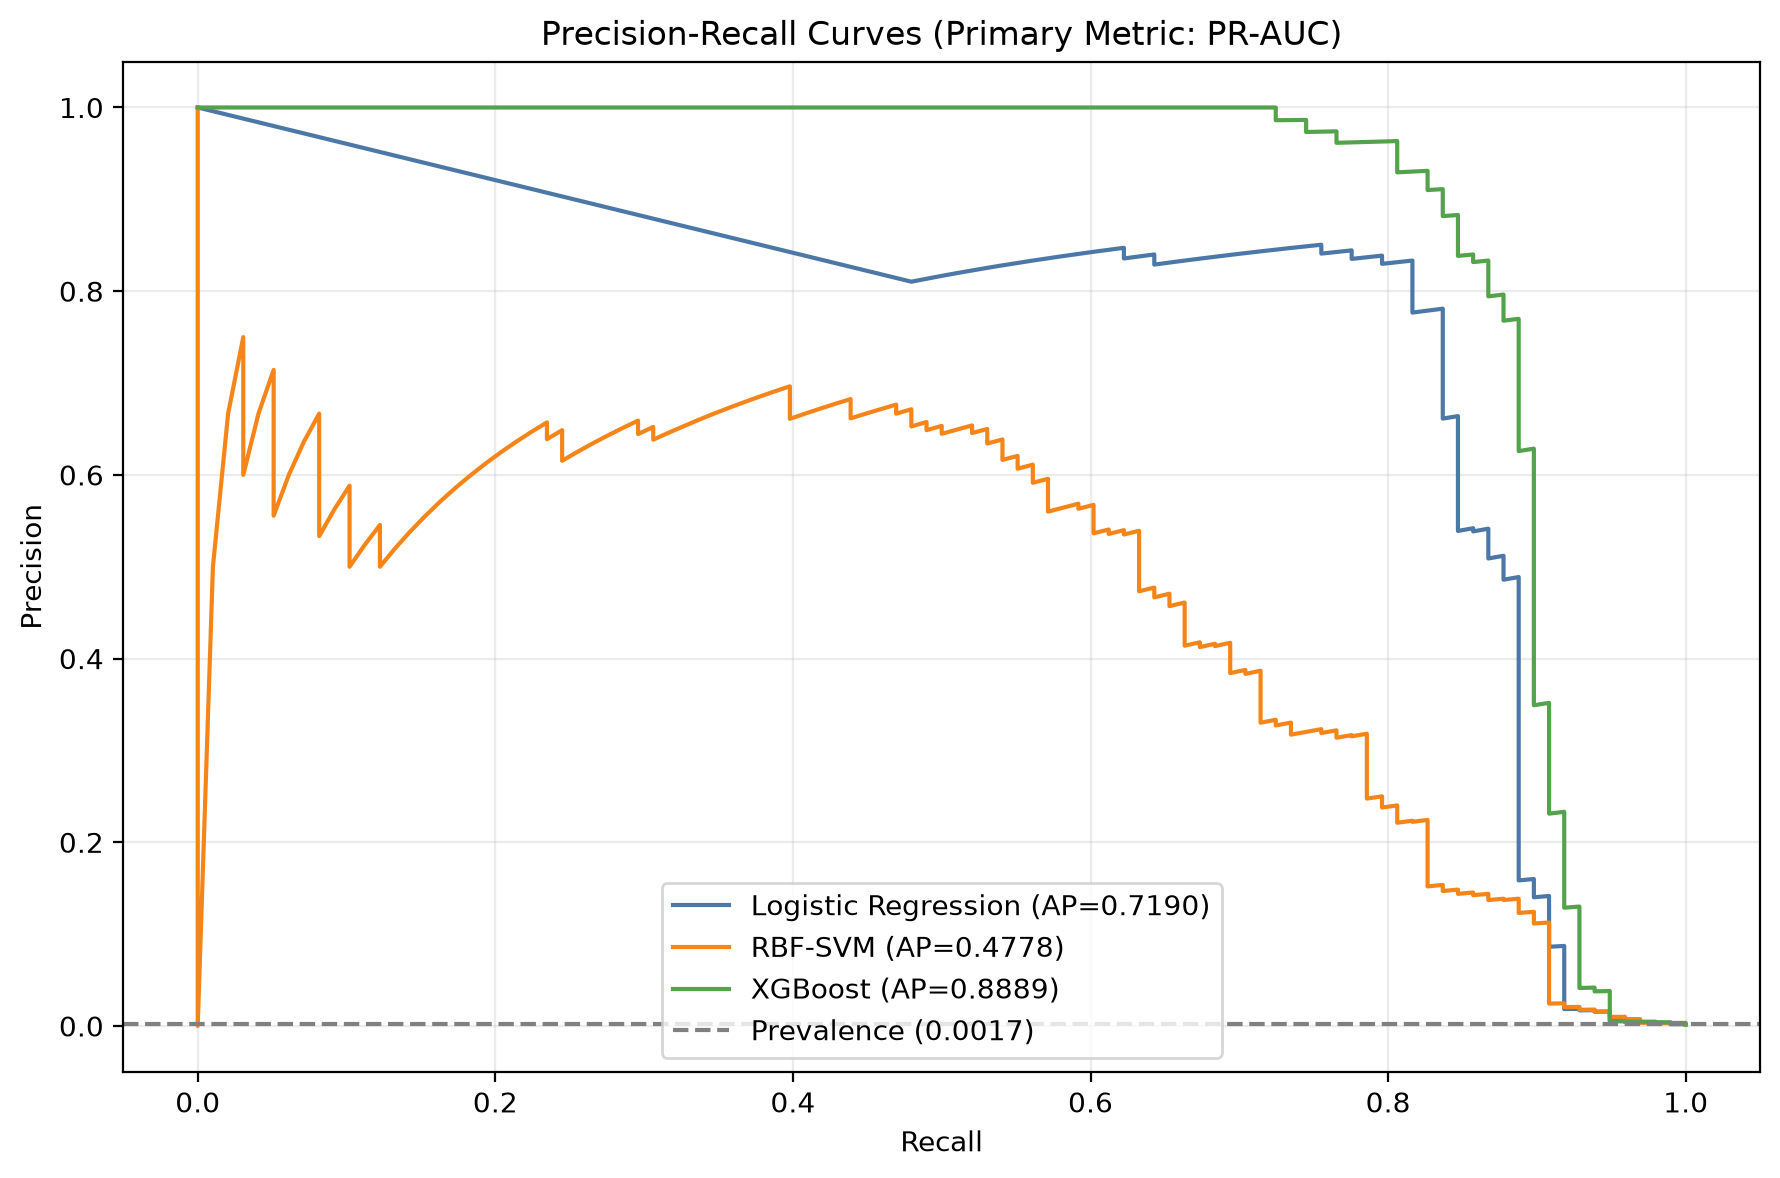

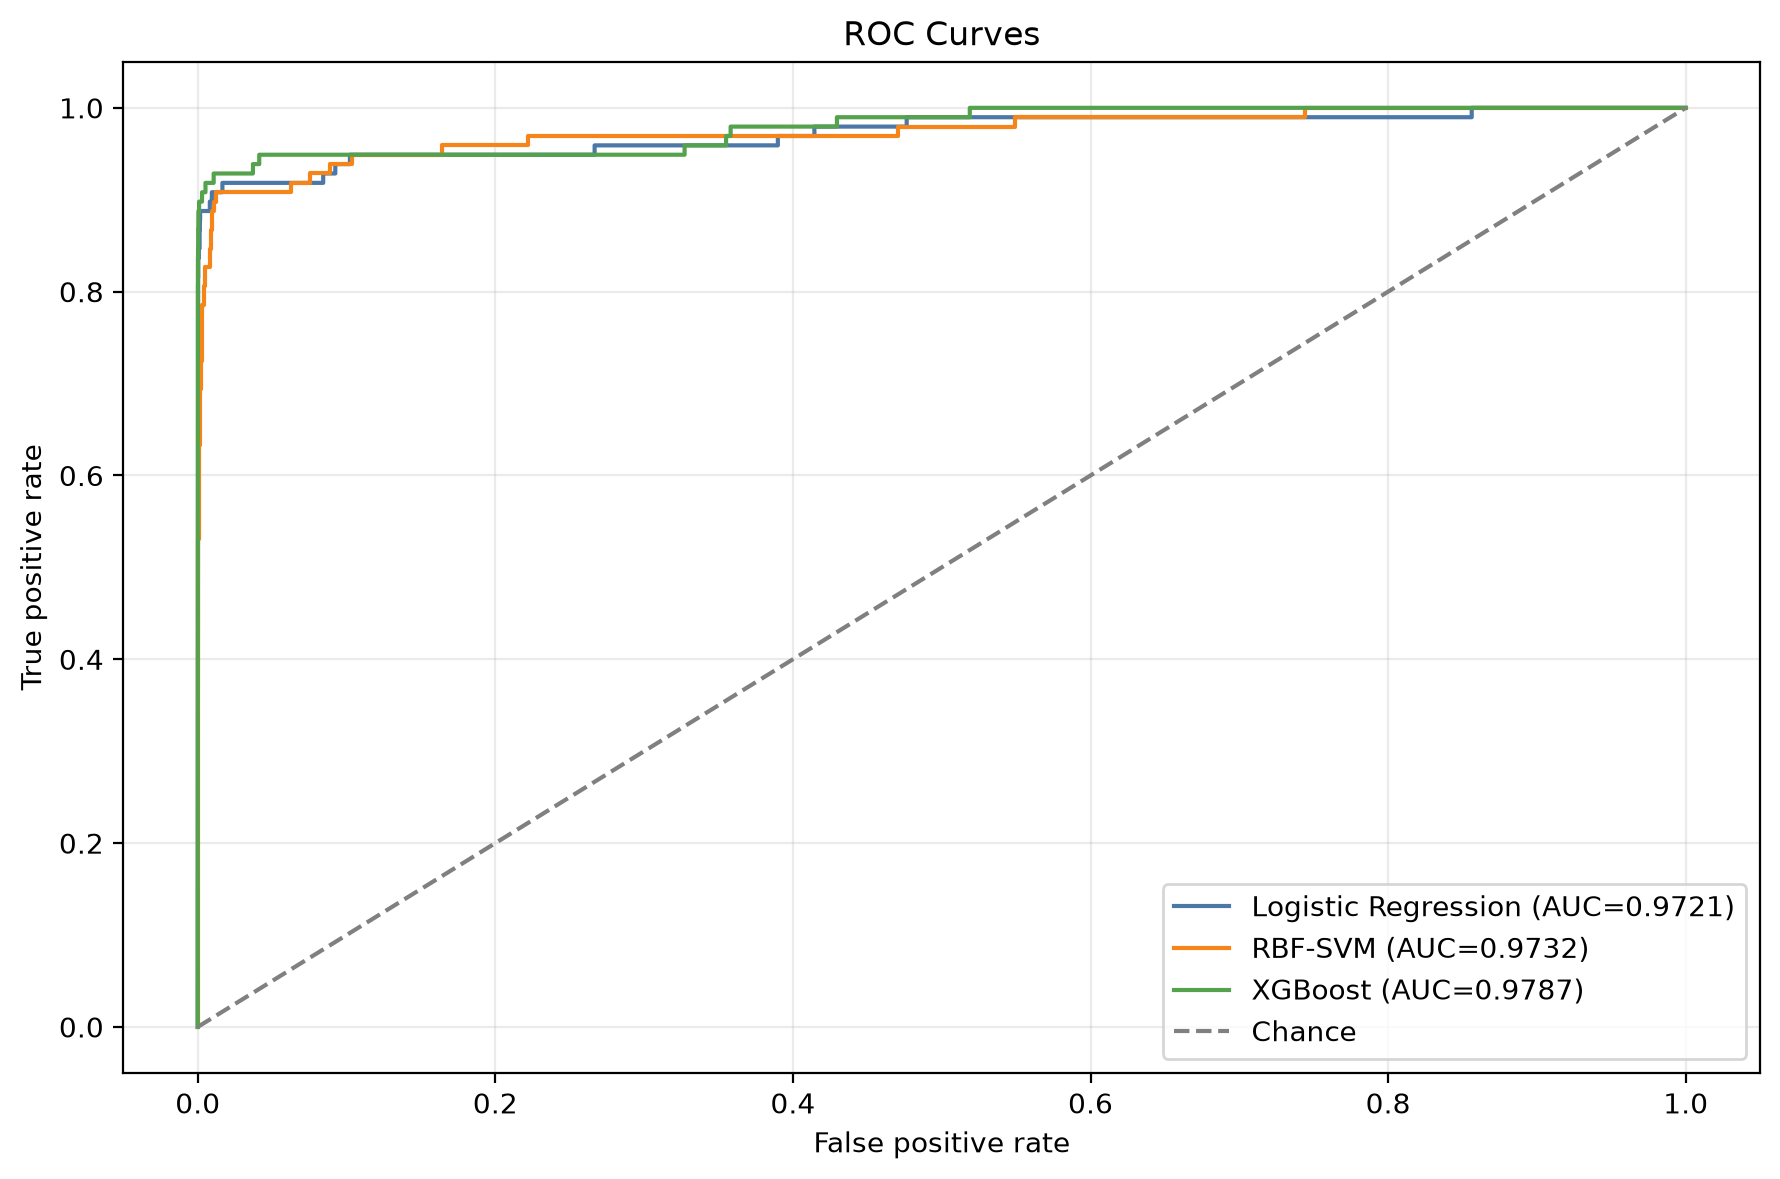

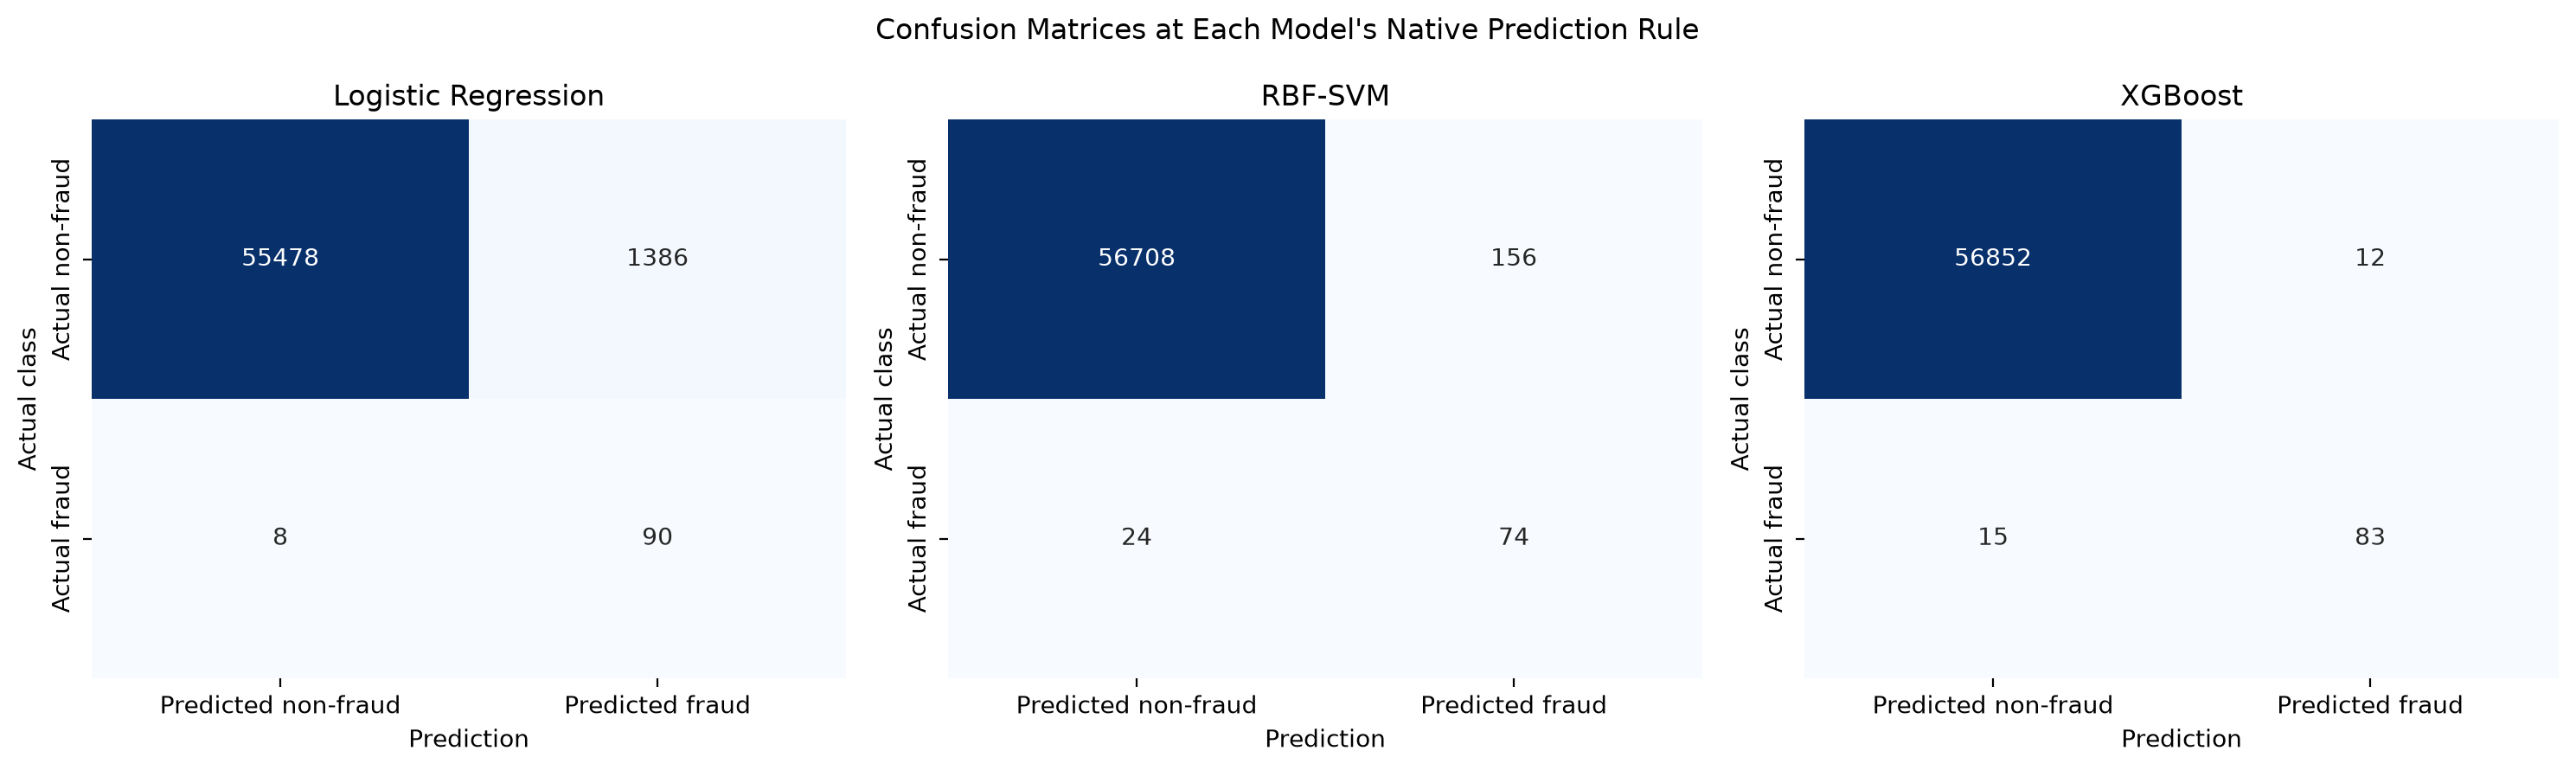

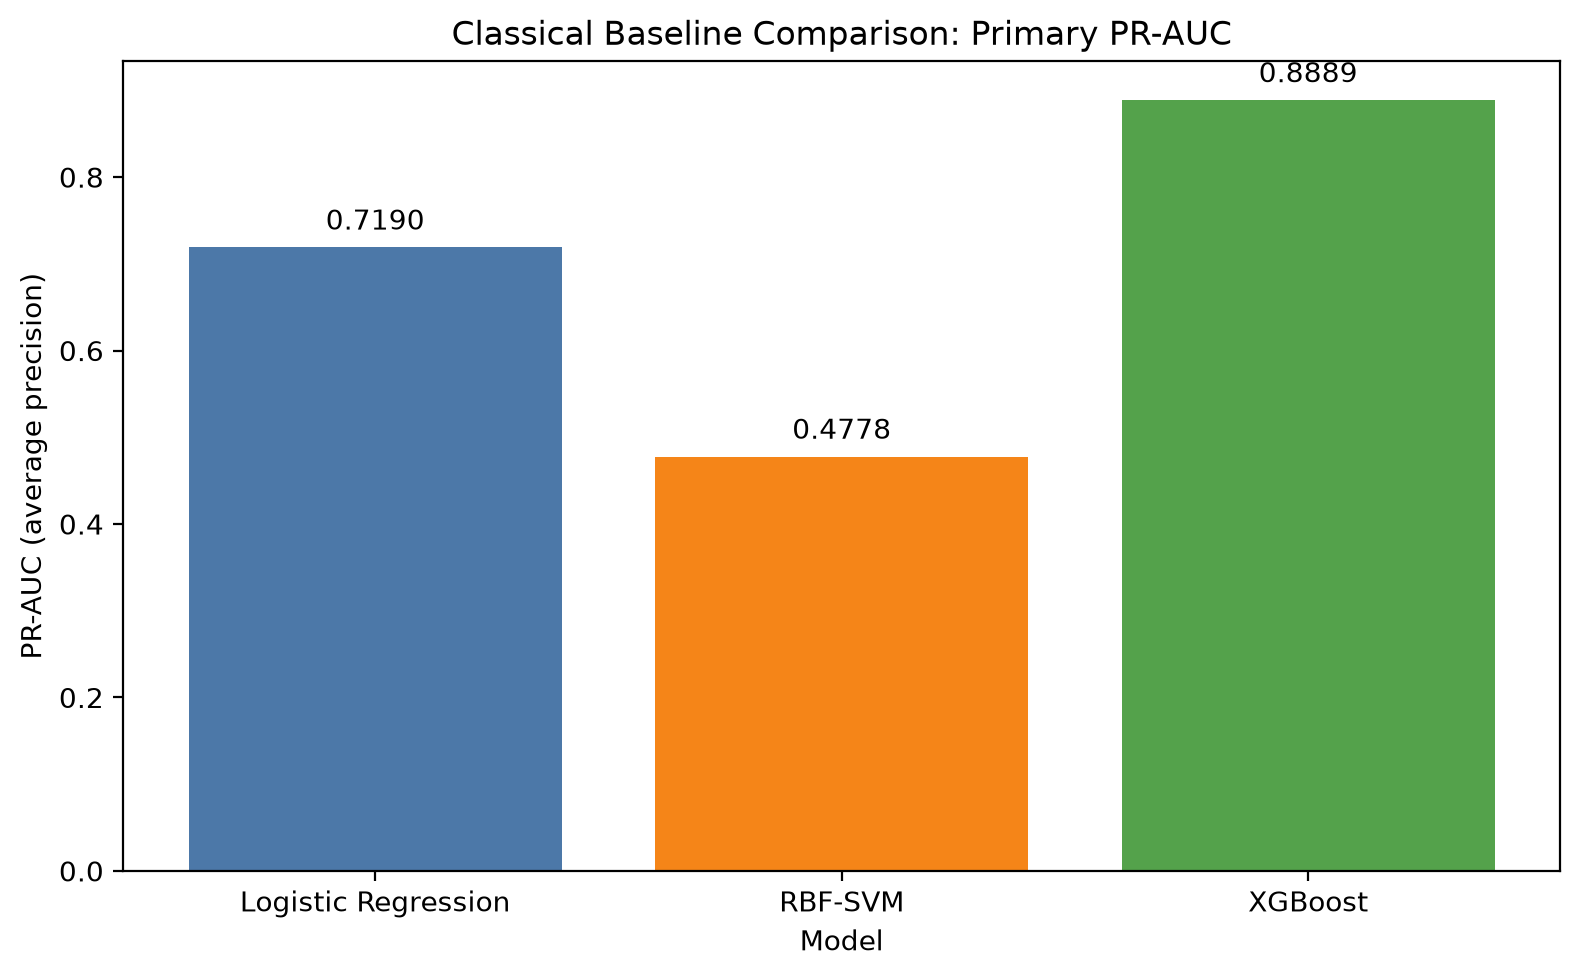

In [9]:
for figure_name in classical_results['figure_files']:
    display(Image(filename=str(CLASSICAL_FIGURES / figure_name), width=700))

## 13. QSVM results

The QSVM result is a reduced-subset preliminary experiment. The 32/32 subsets were required because full quantum-kernel inference over 56,962 test samples was computationally expensive. These metrics are **not directly equivalent** to the full-data classical results and do not establish quantum advantage.

In [10]:
qsvm_metrics = qsvm_results['metrics']
qsvm_table = pd.DataFrame([{
    'PR-AUC': qsvm_metrics['pr_auc'],
    'ROC-AUC': qsvm_metrics['roc_auc'],
    'precision': qsvm_metrics['precision'],
    'recall': qsvm_metrics['recall'],
    'F1': qsvm_metrics['f1'],
    'specificity': qsvm_metrics['specificity'],
    'FPR': qsvm_metrics['false_positive_rate'],
}])
display(qsvm_table)
display(qsvm_results['metrics']['confusion_matrix'])

,PR-AUC,ROC-AUC,precision,recall,F1,specificity,FPR
0,0.538427,0.527344,0.5,0.375,0.428571,0.625,0.375


{'true_negative': 10,
 'false_positive': 6,
 'false_negative': 10,
 'true_positive': 6}

## 14. Model comparison

The saved comparison table is loaded directly. It is factual and intentionally does not rank models or declare a winner. The notes identify that the classical rows are directly matched with each other, while the QSVM row is not directly matched because it uses reduced samples, four features, and a balanced test subset.

In [11]:
display(comparison)

,model,PR-AUC,ROC-AUC,precision,recall,F1,specificity,FPR,training time (seconds),inference time (seconds),feature count,qubit count,training sample count,test sample count,matching/unmatching notes
0,Logistic Regression,0.718971,0.972083,0.060976,0.918367,0.114358,0.975626,0.024374,0.169145,0.001576,30,NaN,227845,56962,Directly matched with RBF-SVM and XGBoost: sam...
1,RBF-SVM,0.477780,0.973191,0.321739,0.755102,0.451220,0.997257,0.002743,22.427630,15.528045,30,NaN,227845,56962,Directly matched with Logistic Regression and ...
2,XGBoost,0.888891,0.978681,0.873684,0.846939,0.860104,0.999789,0.000211,1.309667,0.040751,30,NaN,227845,56962,Directly matched with Logistic Regression and ...
3,Reduced-subset preliminary QSVM,0.538427,0.527344,0.500000,0.375000,0.428571,0.625000,0.375000,0.854267,1.750676,4,4.0,32,32,Not directly equivalent to classical results: ...


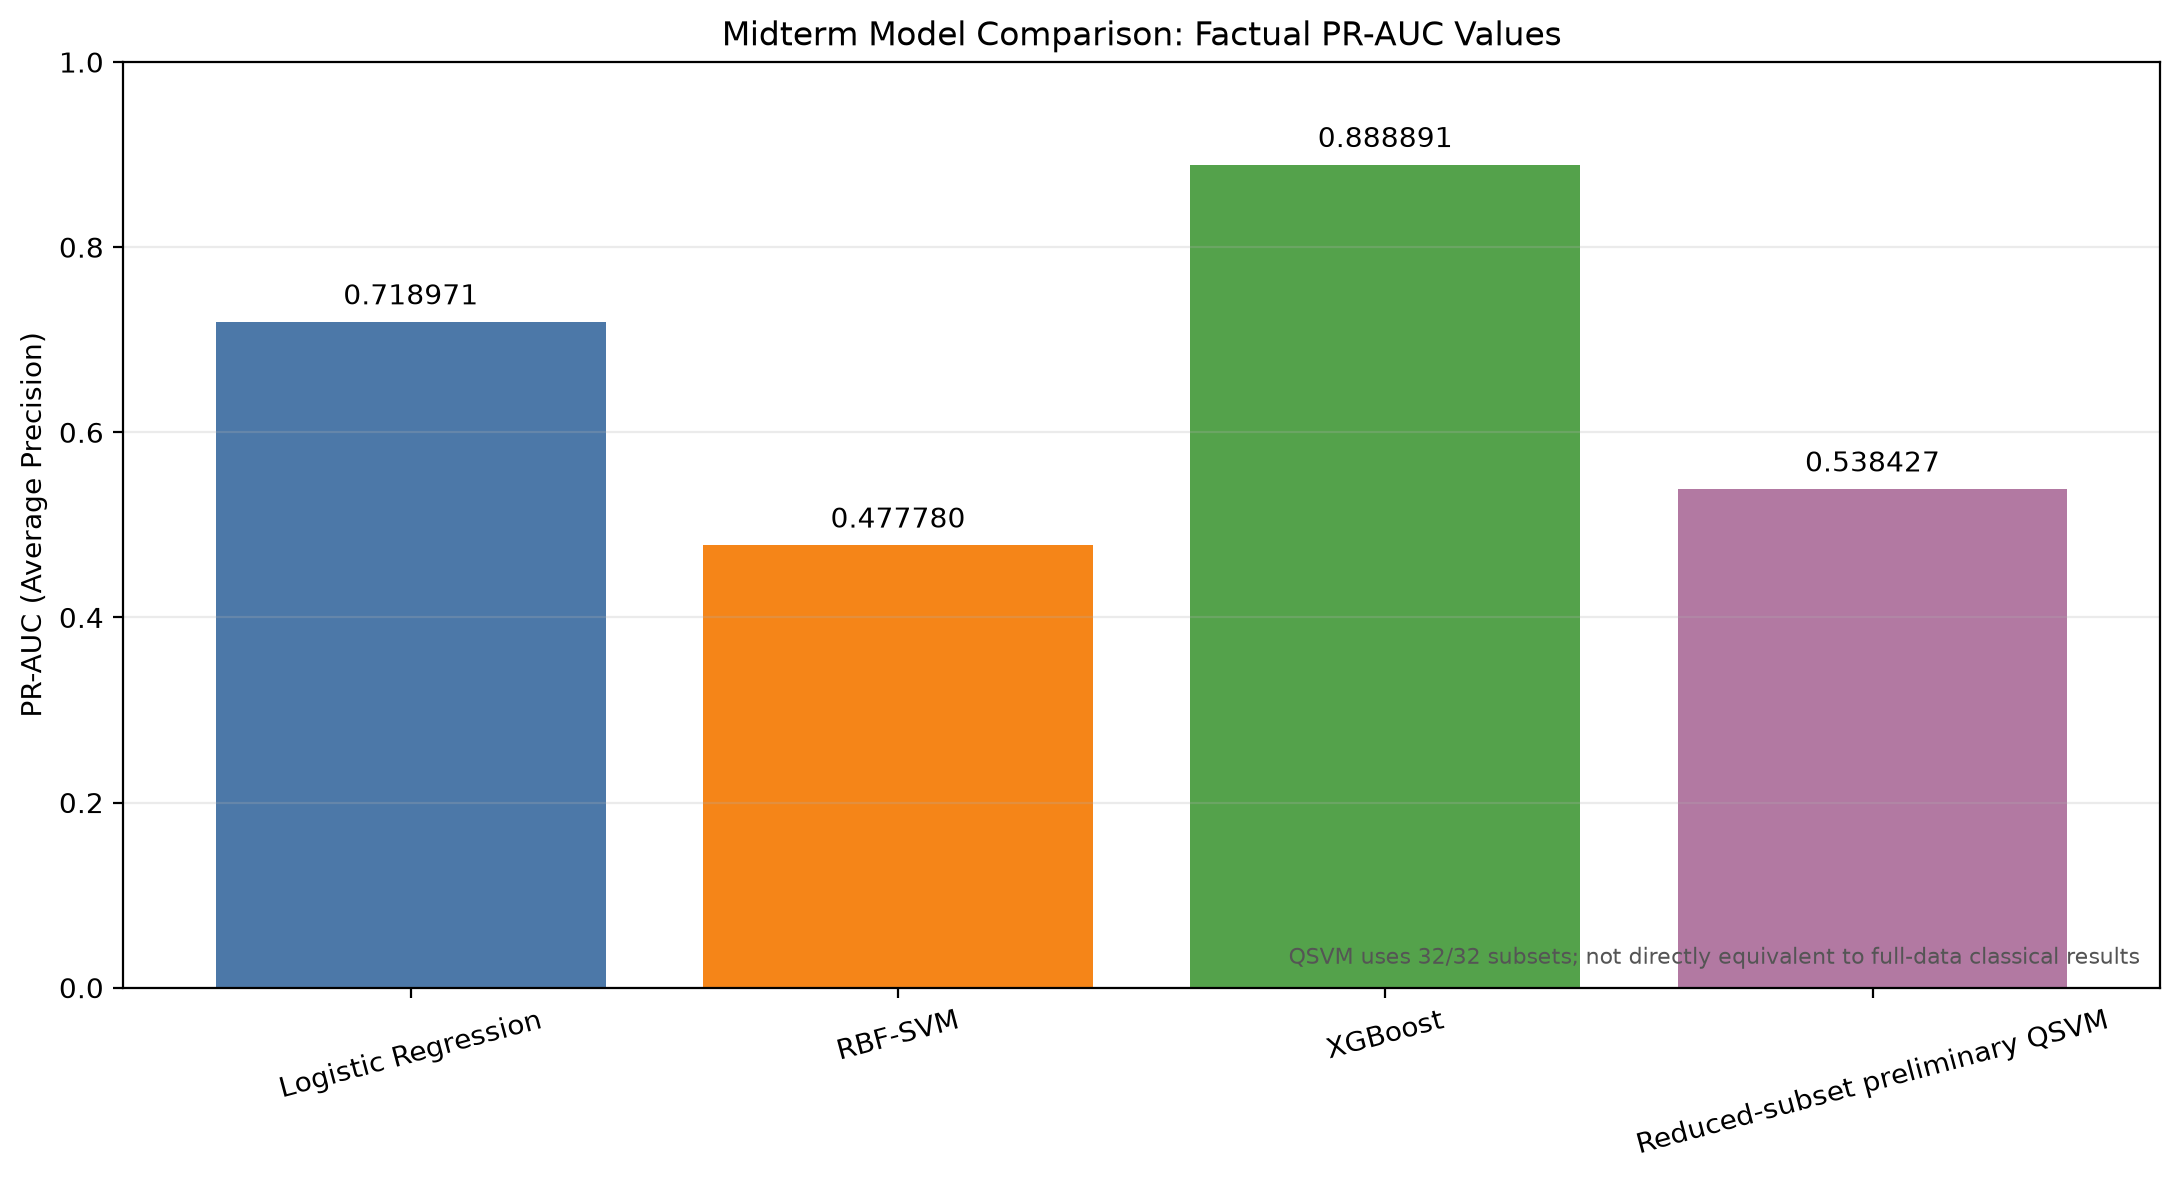

In [12]:
display(Image(filename=str(PROJECT_ROOT / 'results' / 'figures' / 'midterm_model_comparison.png'), width=850))

## 15. Computational cost

The actual saved QSVM timings are shown below. The 32-sample training subset generated 1,024 training-kernel pairs, and the 32-sample test subset required at most 1,024 train-to-test inference pairs. Kernel workload grows with pairwise sample count, which is why this is not a full-data comparison.

In [13]:
timing = qsvm_results['timing_seconds']
cost_table = pd.DataFrame({
    'measurement': ['kernel construction', 'training kernel computation', 'QSVC training', 'inference', 'total runtime'],
    'seconds': [timing['kernel_construction'], timing['training_kernel_matrix'], timing['qsvc_training'], timing['inference'], qsvm_results['total_runtime_seconds']],
})
display(cost_table)

,measurement,seconds
0,kernel construction,0.000213
1,training kernel computation,0.888261
2,QSVC training,0.854267
3,inference,1.750676
4,total runtime,4.578687


## 16. Current limitations

- The QSVM uses reduced 32/32 subsets, so its metrics are not directly equivalent to full-data classical metrics.
- The QSVM test subset is balanced, unlike the original dataset and classical test partition.
- The quantum run is noiseless and uses `StatevectorSampler`; it is not a hardware result and includes no Aer noise.
- No quantum advantage claim is supported.
- The current random split does not measure chronological distribution shift.

## 17. Project status

### COMPLETED

- Dataset validation
- EDA
- Leakage-free preprocessing
- Logistic Regression, RBF-SVM, and XGBoost baselines
- Training-only quantum feature reduction
- QSVM sanity check
- Reduced-subset preliminary QSVM
- Midterm comparison artifacts

### PRELIMINARY

- Reduced-subset QSVM results

### FUTURE

1. Chronological/temporal distribution shift
2. Simulated quantum noise
3. 4/6/8-qubit scaling
4. Computational resource analysis
5. Explainability
6. Optional VQC

Future items have not been implemented or evaluated here.

## 18. Post-midterm research plan

Future phases will define a chronological non-shuffled protocol, add clearly labelled simulated-noise experiments, study qubit/feature scaling, measure computational resources, and consider explainability and an optional VQC. Each phase must preserve training-only decisions and must not be inferred from the current reduced-subset QSVM result.

In [14]:
required_json = ['dataset_summary.json', 'eda_summary.json', 'preprocessing_config.json', 'classical_results.json', 'qsvm_results.json', 'qsvm_predictions.json']
required_tables = ['midterm_model_comparison.csv', 'midterm_model_comparison.md']
assert all((JSON_DIRECTORY / name).exists() for name in required_json)
assert all((TABLES_DIRECTORY / name).exists() for name in required_tables)
assert all((EDA_FIGURES / name).exists() for name in eda_summary['generated_figures'])
assert all((CLASSICAL_FIGURES / name).exists() for name in classical_results['figure_files'])
assert all((PROJECT_ROOT / name).exists() for name in qsvm_results['figure_files'].values())
assert (PROJECT_ROOT / 'results' / 'figures' / 'midterm_model_comparison.png').exists()
print('All referenced JSON, table, and figure artifacts exist.')
print('No completed model was retrained and no new QSVM experiment was launched.')

All referenced JSON, table, and figure artifacts exist.
No completed model was retrained and no new QSVM experiment was launched.
